1. Predict Weight using Height (Linear Regression).

In [1]:
import pandas as pd
df =pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [2]:
X = df[['Height']]
y = df['Weight']

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, random_state = 0)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

[148.7894772  168.43520123 224.31884497 ... 159.17576427 155.86404539
 144.83449257]


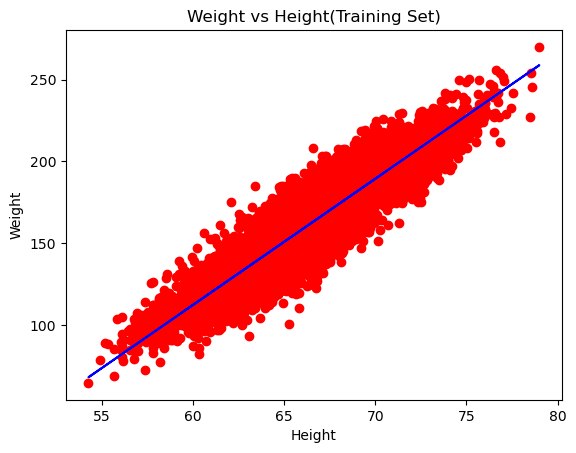

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X_train,y_train, color = "red")
plt.plot(X_train, model.predict(X_train), color = 'blue')
plt.title("Weight vs Height(Training Set)")
plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()

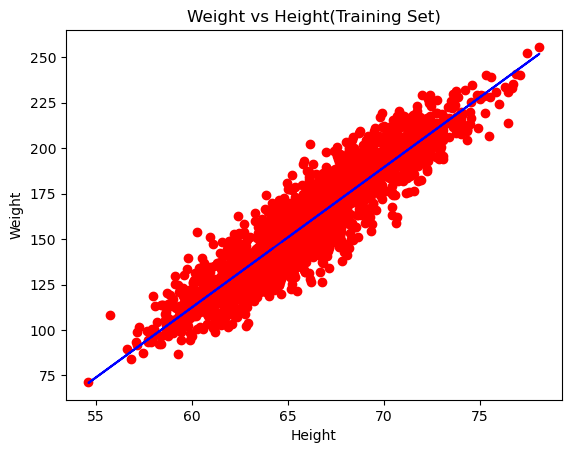

In [6]:
plt.scatter(X_test,y_test, color = "red")
plt.plot(X_test, model.predict(X_test), color = 'blue')
plt.title("Weight vs Height(Training Set)")
plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()

2. Perfrom Naive Bayes Classification and Logistic Regression to predict if a bank customer would "churn" (i.e. close bank account) using dataset "Bank Customer Churn Prediction". Perform encoding and scaling as appropriate. Handle nulls, if present.


In [59]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

bank_df = pd.read_csv('Bank Customer Churn Prediction.csv')
bank_df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [60]:
#for credit score
credit_score = bank_df[['credit_score']]
standard_scaler = StandardScaler()
bank_df['credit_score_scaled'] = standard_scaler.fit_transform(credit_score)
bank_df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,credit_score_scaled
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,-0.326221
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,-0.440036
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,-1.536794
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.501521
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2.063884


In [61]:
#for country
label_encoder = LabelEncoder()
bank_df['country_label'] = label_encoder.fit_transform(bank_df['country'])
print("\nLabel Encoder 'country':\n", bank_df[['country','country_label']].head())
print("\nLabel Encoder 'country':\n", bank_df[['country','country_label']].tail())


Label Encoder 'country':
   country  country_label
0  France              0
1   Spain              2
2  France              0
3  France              0
4   Spain              2

Label Encoder 'country':
       country  country_label
9995   France              0
9996   France              0
9997   France              0
9998  Germany              1
9999   France              0


In [62]:
#for gender
label_encoder = LabelEncoder()
bank_df['gender_label'] = label_encoder.fit_transform(bank_df['gender'])
print("\nLabel Encoder 'gender':\n", bank_df[['gender','gender_label']].head())
print("\nLabel Encoder 'gender':\n", bank_df[['gender','gender_label']].tail())


Label Encoder 'gender':
    gender  gender_label
0  Female             0
1  Female             0
2  Female             0
3  Female             0
4  Female             0

Label Encoder 'gender':
       gender  gender_label
9995    Male             1
9996    Male             1
9997  Female             0
9998    Male             1
9999  Female             0


In [63]:
#for age
age = bank_df[['age']]
standard_scaler = StandardScaler()
bank_df['age_scaled'] = standard_scaler.fit_transform(age)
bank_df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,credit_score_scaled,country_label,gender_label,age_scaled
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,-0.326221,0,0,0.293517
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,-0.440036,2,0,0.198164
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,-1.536794,0,0,0.293517
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.501521,0,0,0.007457
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2.063884,2,0,0.388871


In [64]:
#for balance
balance = bank_df[['balance']]
standard_scaler = StandardScaler()
bank_df['balance_scaled'] = standard_scaler.fit_transform(balance)
bank_df.head()

#for salary
salary = bank_df[['estimated_salary']]
standard_scaler = StandardScaler()
bank_df['estimated_salary_scaled'] = standard_scaler.fit_transform(salary)
bank_df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,credit_score_scaled,country_label,gender_label,age_scaled,balance_scaled,estimated_salary_scaled
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,-0.326221,0,0,0.293517,-1.225848,0.021886
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,-0.440036,2,0,0.198164,0.117350,0.216534
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,-1.536794,0,0,0.293517,1.333053,0.240687
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.501521,0,0,0.007457,-1.225848,-0.108918
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2.063884,2,0,0.388871,0.785728,-0.365276


In [78]:
#features
X = bank_df[['credit_score_scaled', 'country_label', 'gender_label','age_scaled','balance_scaled','active_member','estimated_salary_scaled','tenure','products_number']]
y = bank_df['churn']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2, random_state = 42, stratify=y)
print("Training set size :", len(X_train))
print("Testing set size :", len(X_test))

Training set size : 8000
Testing set size : 2000


In [80]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [81]:
y_pred = model.predict(X_test)
accuracy =accuracy_score(y_test, y_pred)
print("Accuracy Result: ", accuracy)

Accuracy Result:  0.83


In [84]:
#Using Logistic Regression Model
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [85]:
y_pred = lr.predict(X_test)
accuracy =accuracy_score(y_test, y_pred)
print("Accuracy Result: ", accuracy)

Accuracy Result:  0.805


In [89]:
#Question 3. 
df_t = pd.read_csv("TravelInsurancePrediction.csv")
df_t.columns

Index(['Unnamed: 0', 'Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome',
       'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'TravelInsurance'],
      dtype='object')

In [88]:
df_t.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


In [90]:
#Age column
age = df_t[['Age']]
standard_scaler = StandardScaler()
df_t['age_scaled'] = standard_scaler.fit_transform(age)
df_t.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,age_scaled
0,0,31,Government Sector,Yes,400000,6,1,No,No,0,0.463430
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,0.463430
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,1.493446
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0,-0.566587
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0,-0.566587


In [92]:
df_t['Employment Type'].unique()

array(['Government Sector', 'Private Sector/Self Employed'], dtype=object)

In [94]:
#Employement Type
label_encoder = LabelEncoder()
df_t['emp_label'] = label_encoder.fit_transform(df_t['Employment Type'])
print("\nLabel Encoder 'Employment Type':\n", df_t[['Employment Type','emp_label']].head())
print("\nLabel Encoder 'Employment Type':\n", df_t[['Employment Type','emp_label']].tail())


Label Encoder 'Employment Type':
                 Employment Type  emp_label
0             Government Sector          0
1  Private Sector/Self Employed          1
2  Private Sector/Self Employed          1
3  Private Sector/Self Employed          1
4  Private Sector/Self Employed          1

Label Encoder 'Employment Type':
                    Employment Type  emp_label
1982  Private Sector/Self Employed          1
1983  Private Sector/Self Employed          1
1984  Private Sector/Self Employed          1
1985  Private Sector/Self Employed          1
1986  Private Sector/Self Employed          1


In [95]:
#Annual Income
income = df_t[['AnnualIncome']]
standard_scaler = StandardScaler()
df_t['income_scaled'] = standard_scaler.fit_transform(income)
df_t.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,age_scaled,emp_label,income_scaled
0,0,31,Government Sector,Yes,400000,6,1,No,No,0,0.463430,0,-1.414061
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,0.463430,1,0.842012
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,1.493446,1,-1.148641
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0,-0.566587,1,-0.617800
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0,-0.566587,1,-0.617800


In [96]:
#Family Members
fam = df_t[['FamilyMembers']]
standard_scaler = StandardScaler()
df_t['fam_scaled'] = standard_scaler.fit_transform(fam)
df_t.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,age_scaled,emp_label,income_scaled,fam_scaled
0,0,31,Government Sector,Yes,400000,6,1,No,No,0,0.463430,0,-1.414061,0.774964
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,0.463430,1,0.842012,1.396373
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,1.493446,1,-1.148641,-0.467855
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0,-0.566587,1,-0.617800,-1.089265
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0,-0.566587,1,-0.617800,2.017783


In [97]:
#Frequent Flyer
label_encoder = LabelEncoder()
df_t['fly_label'] = label_encoder.fit_transform(df_t['FrequentFlyer'])
print("\nLabel Encoder 'Frequent Flyer':\n", df_t[['FrequentFlyer','fly_label']].head())
print("\nLabel Encoder 'Frequent Flyer':\n", df_t[['FrequentFlyer','fly_label']].tail())


Label Encoder 'Frequent Flyer':
   FrequentFlyer  fly_label
0            No          0
1            No          0
2            No          0
3            No          0
4           Yes          1

Label Encoder 'Frequent Flyer':
      FrequentFlyer  fly_label
1982           Yes          1
1983            No          0
1984            No          0
1985           Yes          1
1986            No          0


In [108]:
#EverTravelledAbroad
label_encoder = LabelEncoder()
df_t['freq_label'] = label_encoder.fit_transform(df_t['EverTravelledAbroad'])
print("\nLabel Encoder 'Ever Travelled Abroad':\n", df_t[['EverTravelledAbroad','freq_label']].head())
print("\nLabel Encoder 'Ever Travelled Abroad':\n", df_t[['EverTravelledAbroad','freq_label']].tail())


Label Encoder 'Ever Travelled Abroad':
   EverTravelledAbroad  freq_label
0                  No           0
1                  No           0
2                  No           0
3                  No           0
4                  No           0

Label Encoder 'Ever Travelled Abroad':
      EverTravelledAbroad  freq_label
1982                 Yes           1
1983                 Yes           1
1984                  No           0
1985                 Yes           1
1986                  No           0


In [109]:
df_t.columns

Index(['Unnamed: 0', 'Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome',
       'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'TravelInsurance', 'age_scaled', 'emp_label',
       'income_scaled', 'fam_scaled', 'fly_label', 'freq_label'],
      dtype='object')

In [110]:
X =df_t[['age_scaled', 'emp_label', 'income_scaled', 'fam_scaled', 'ChronicDiseases','fly_label', 'freq_label']]
y = df_t['TravelInsurance']

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state =42, stratify =y)

In [112]:
model.fit(X_train, y_train)

GaussianNB()

In [113]:
y_pred = model.predict(X_test)

In [114]:
accuracy =accuracy_score(y_test, y_pred)
print("Accuracy Result: ", accuracy)

Accuracy Result:  0.7437185929648241


In [115]:
lr.fit(X_train,y_train)

LogisticRegression(max_iter=500)

In [116]:
ly_pred = lr.predict(X_test)
accuracy =accuracy_score(y_test, ly_pred)
print("Accuracy Result: ", accuracy)

Accuracy Result:  0.7613065326633166
